# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Vincent Valentino|5054251016|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [34]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from scipy.stats import chi2_contingency

In [35]:
mushroom = pd.read_csv("mushrooms.csv")
mushroom.shape

(8124, 23)

In [36]:
mushroom.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [37]:
mushroom.dtypes

class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

In [38]:
mushroom.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Berdasarkan informasi mengenai dataset dari https://archive.ics.uci.edu/dataset/73/mushroom, kolom `stalk-root` mengandung missing values yang tidak direpresentasikan sebagai `NaN.` tetapi ditandai dengan `?`, sehingga tidak teridentifikasi sebagai missing values ketika menggunakan fungsi describe().

In [39]:
mcount = (mushroom == "?").sum()
mpercentage = (mushroom == "?").mean() * 100

pd.DataFrame({
    "Count": mcount,
    "Percentage": mpercentage
})


,Count,Percentage
class,0,0.000000
cap-shape,0,0.000000
cap-surface,0,0.000000
cap-color,0,0.000000
bruises,0,0.000000
odor,0,0.000000
gill-attachment,0,0.000000
gill-spacing,0,0.000000
gill-size,0,0.000000
gill-color,0,0.000000


In [40]:
mushroom.duplicated().sum()

np.int64(0)

Tidak ada duplicates, jadi tidak perlu dihapus

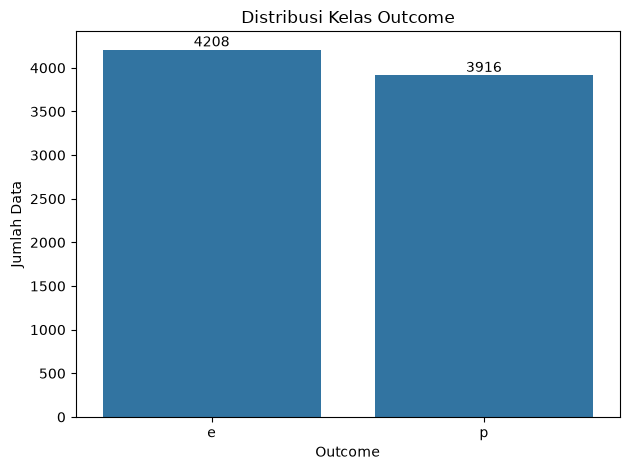

In [62]:
values = mushroom["class"].value_counts().reset_index()
ax = sb.barplot(data=values, x="class", y="count")
ax.set_title("Distribusi Kelas Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Jumlah Data")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Sedikit imbalanced dengan e sedikit lebih banyak dibanding p, tetapi juga akan di-stratify

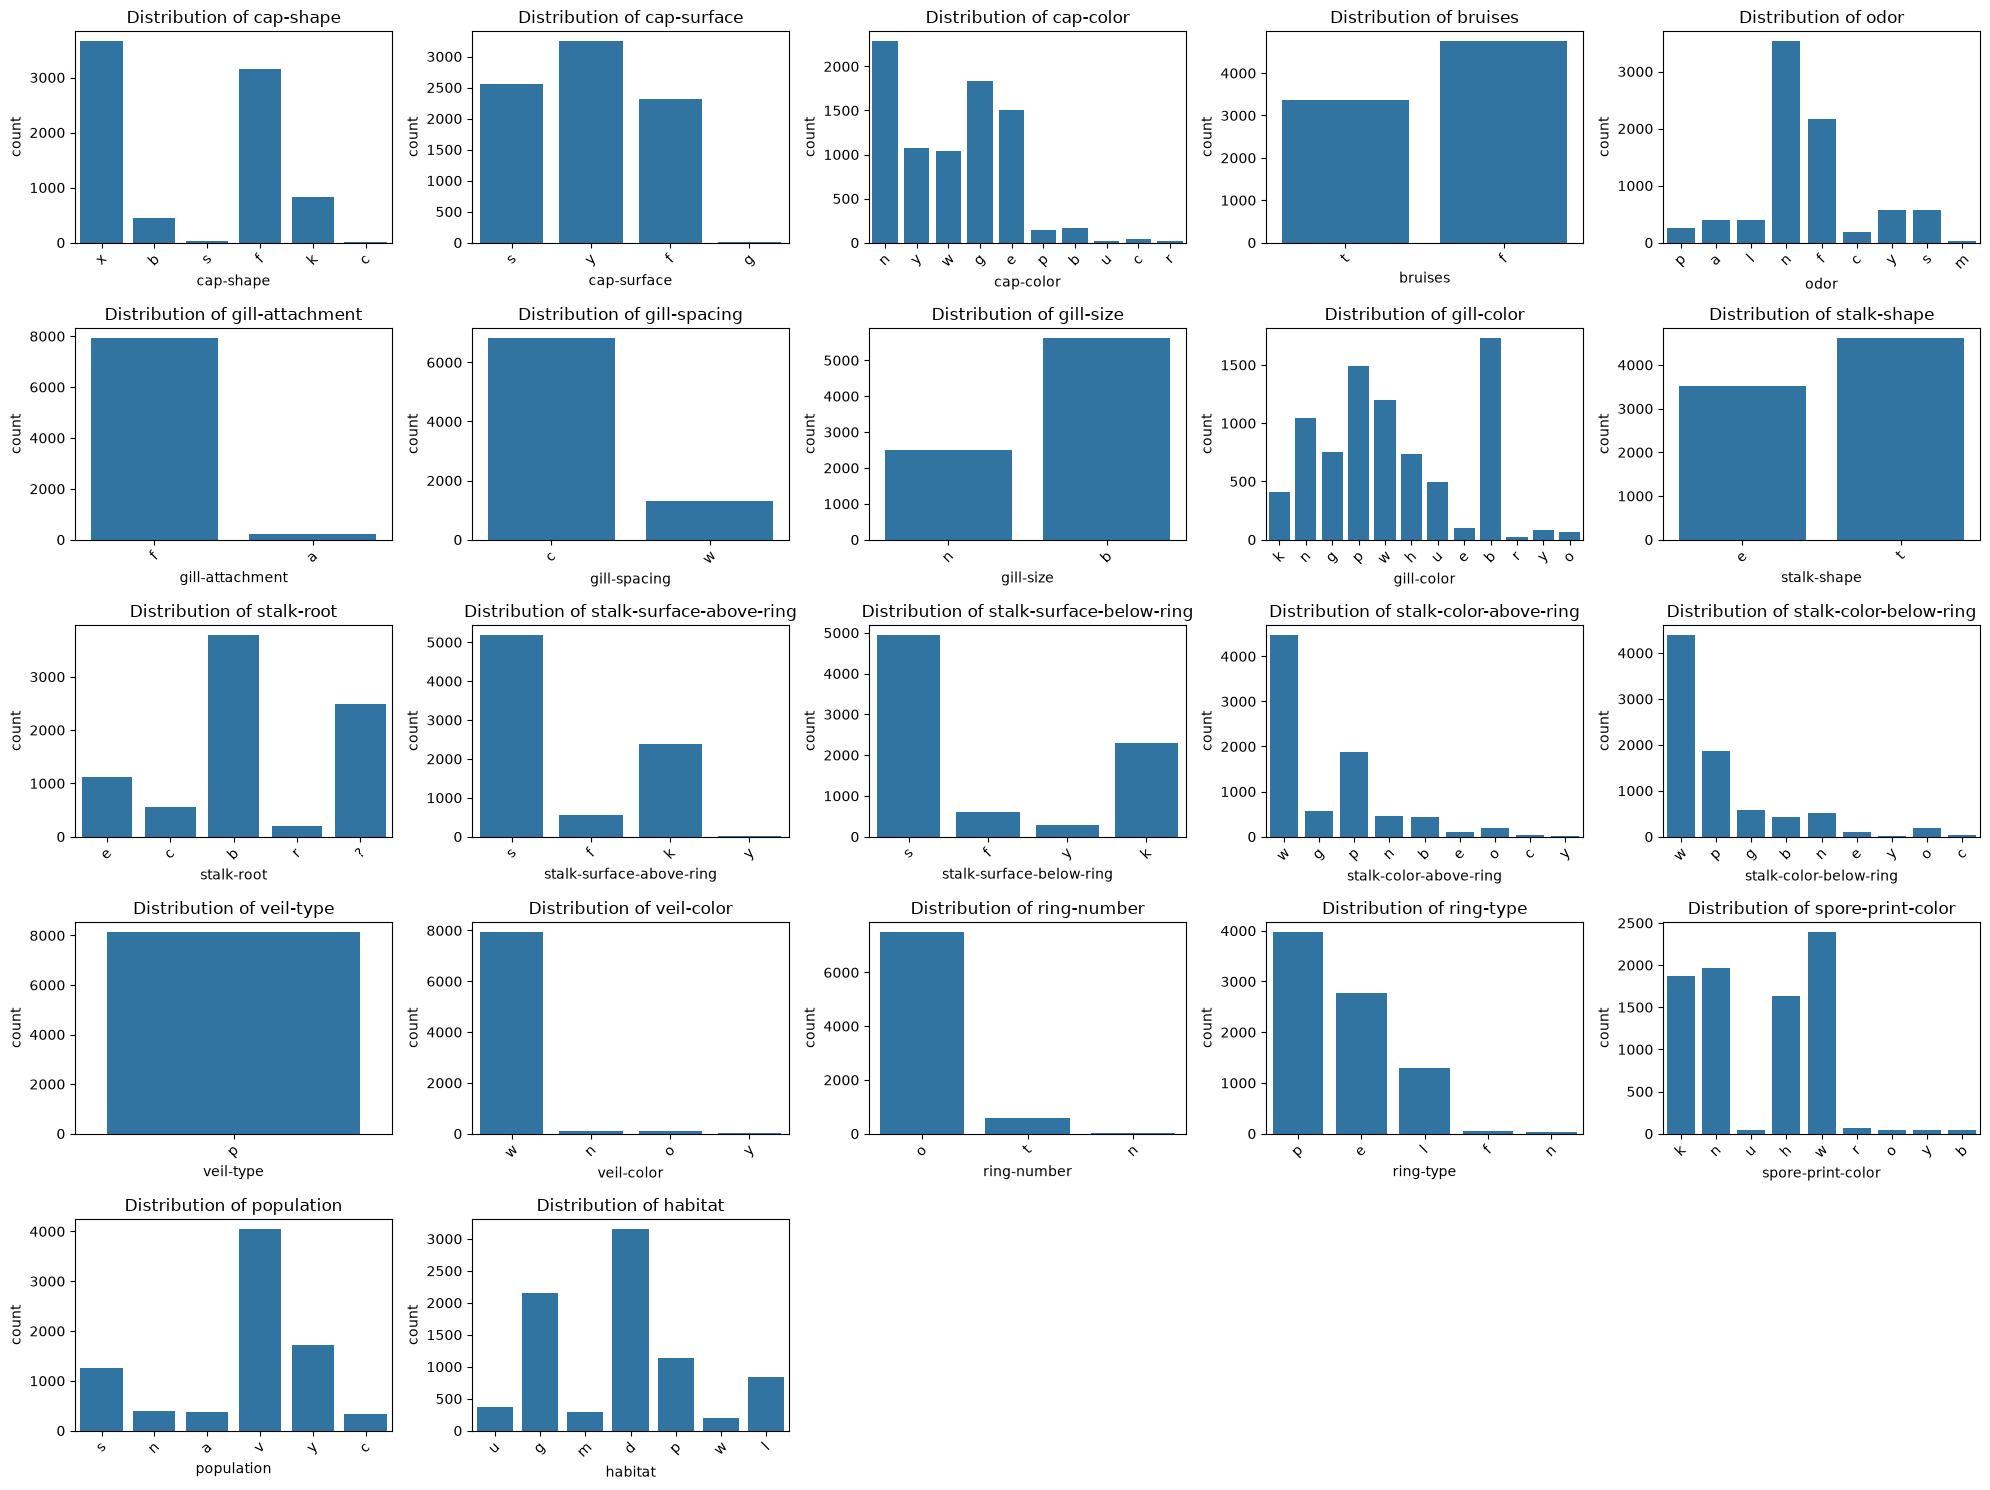

In [42]:
df = mushroom.drop(columns = "class")
fig, axes = plt.subplots(5,5, figsize=(20,15))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    if col != 'class':
        sb.countplot(data=mushroom, x=col, ax=ax)
        ax.set_title(f"Distribution of {col}")
        ax.tick_params(axis='x', rotation=45)

for i in range(len(axes)):
    if i >= len(df.columns):
        axes[i].axis('off')

plt.tight_layout()
plt.show()

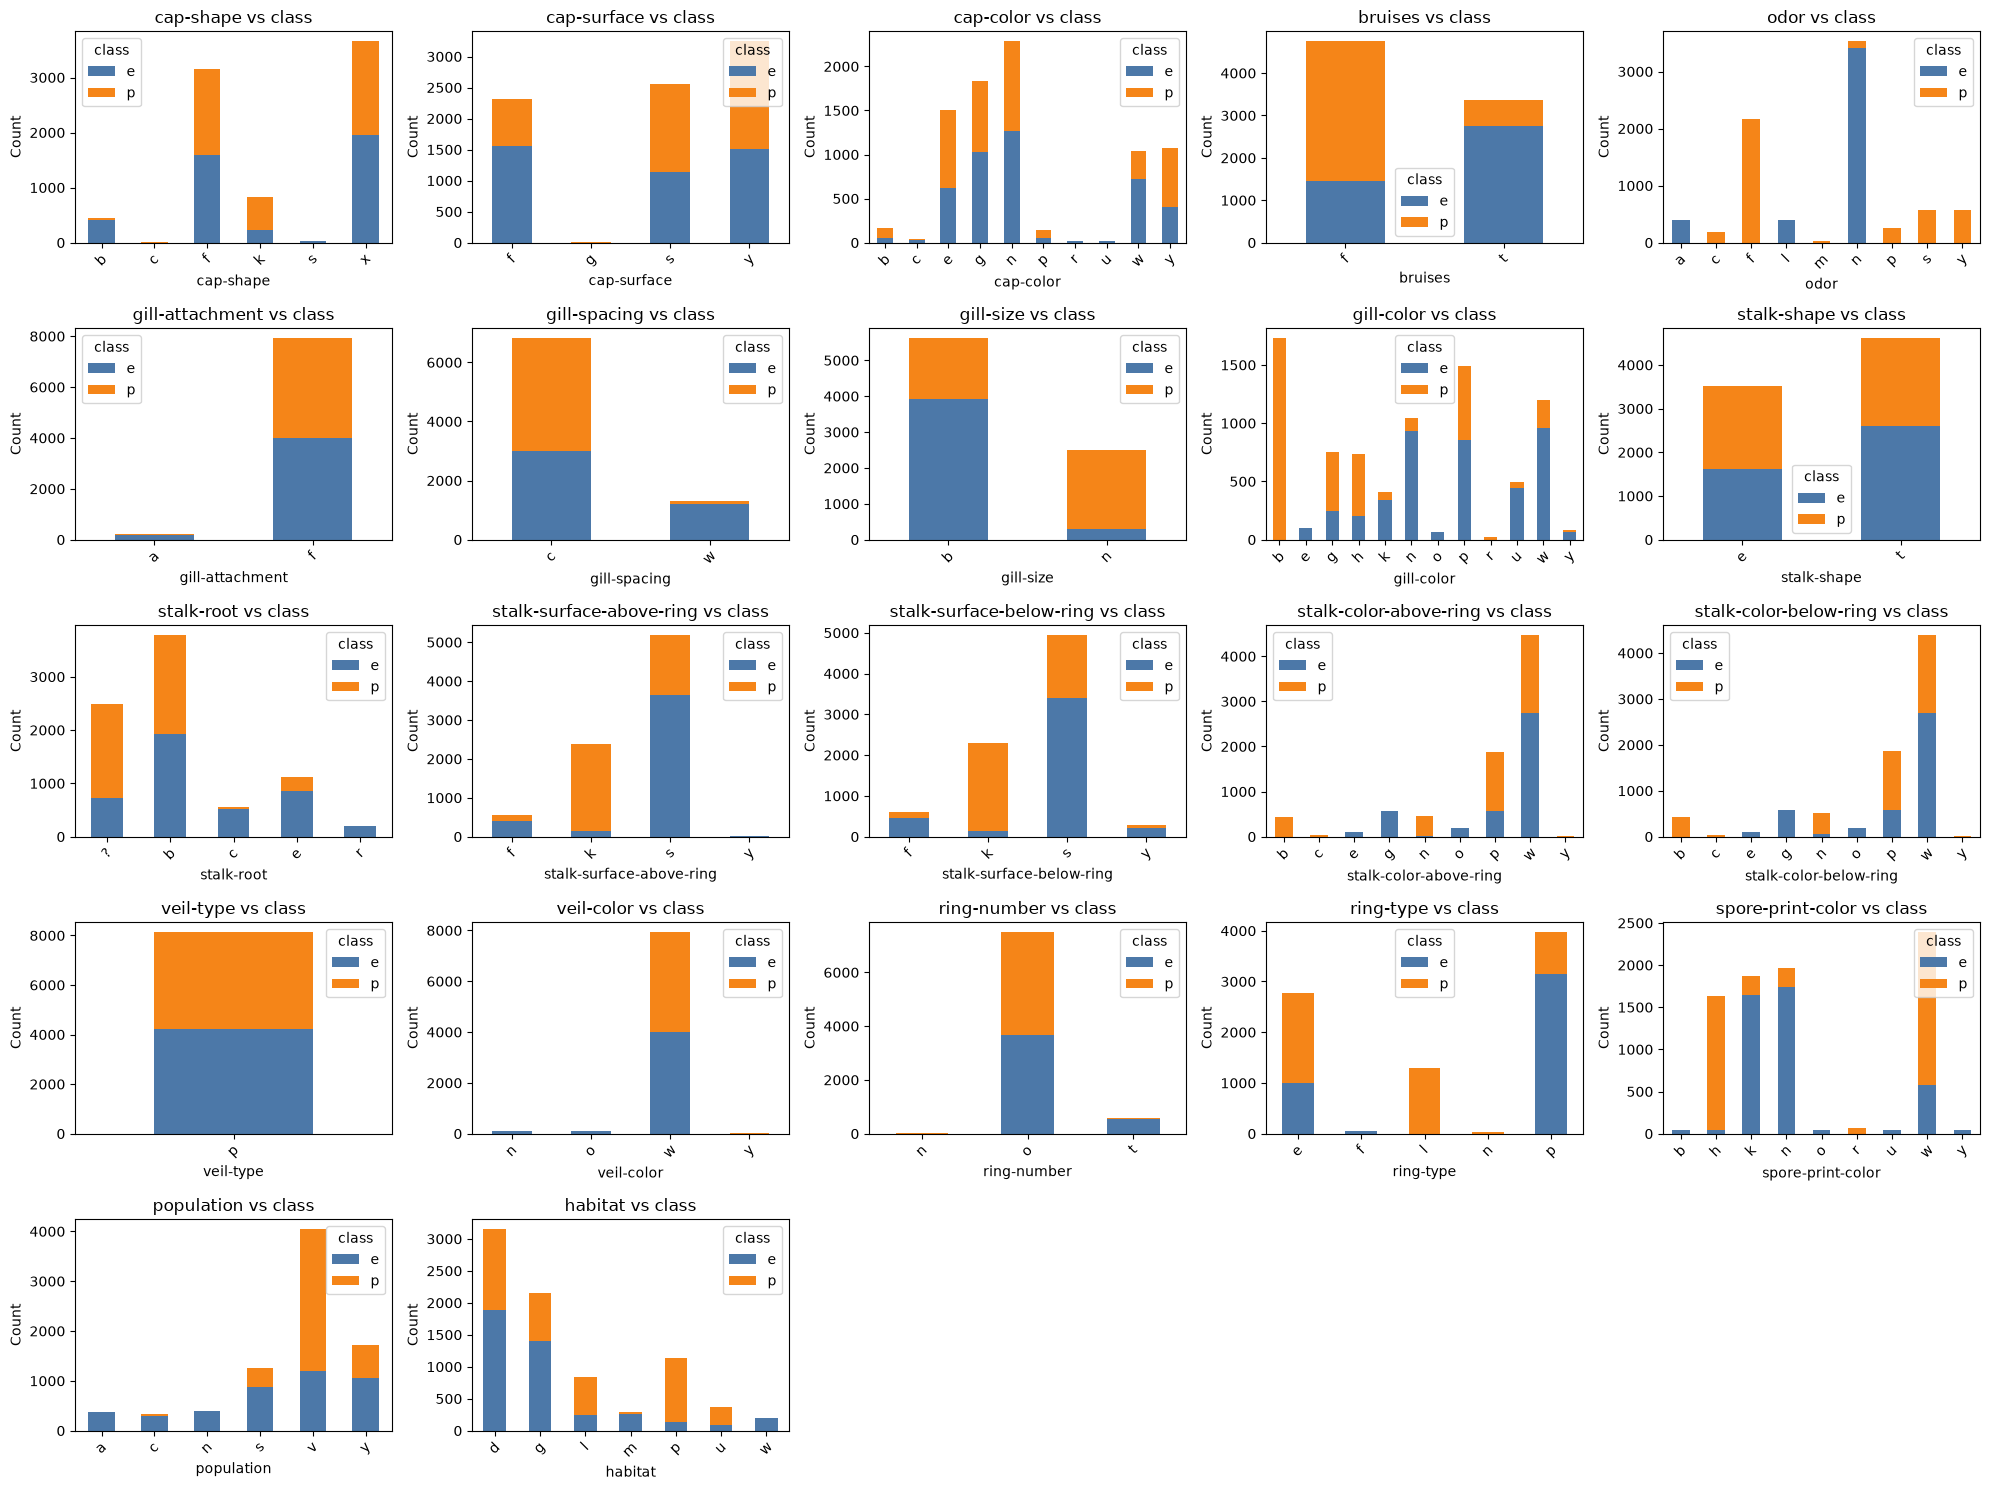

In [43]:
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    crosstab = pd.crosstab(mushroom[col], mushroom["class"])
    crosstab.plot(kind="bar", stacked=True, ax=ax, color=["#4C78A8", "#F58518"])
    ax.set_title(f"{col} vs class")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="class")

for i in range(len(df.columns), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


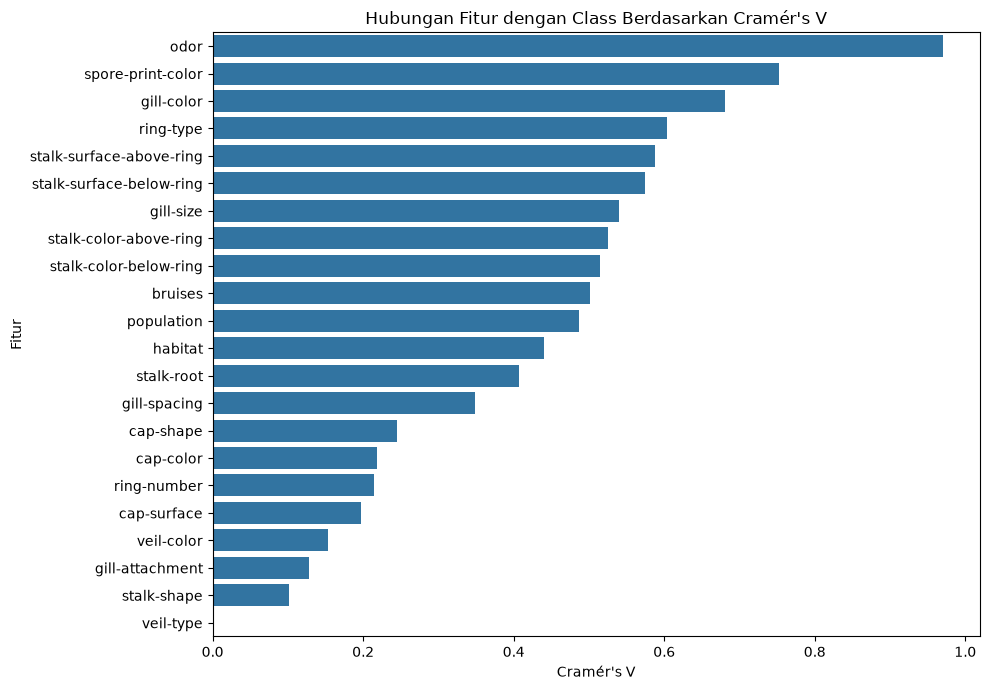

In [44]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    denominator = min(r - 1, k - 1)
    return np.sqrt((chi2 / n) / denominator) if denominator > 0 else 0

cramers_results = pd.Series({
    col: cramers_v(mushroom[col], mushroom["class"])
    for col in mushroom.columns
    if col != "class"
}).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sb.barplot(x=cramers_results.values,y=cramers_results.index)
plt.title("Hubungan Fitur dengan Class Berdasarkan Cramér's V")
plt.xlabel("Cramér's V")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

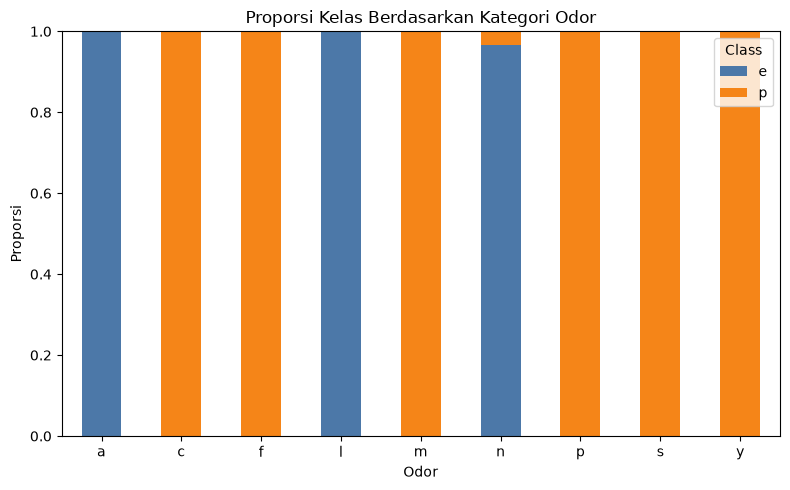

In [45]:
odor_class = pd.crosstab(
    mushroom["odor"],
    mushroom["class"],
    normalize="index"
)

odor_class.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#4C78A8", "#F58518"]
)

plt.title("Proporsi Kelas Berdasarkan Kategori Odor")
plt.xlabel("Odor")
plt.ylabel("Proporsi")
plt.legend(title="Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

Berdasarkan hasil pengecekan missing value, ditemukan bahwa `?` di `stalk-root` mencapai sekitar 30,5% dari keseluruhan data. Jika missing values tersebut dihapus, jumlah data yang hilang akan cukup besar dan berpotensi mengurangi representasi dataset. Sementara itu, mengganti nilai ? dengan modus dapat menyebabkan informasi yang dihasilkan menjadi kurang akurat. Sehingga, missing value tersebut akan dibuat kategori sendiri.

In [46]:
mush = mushroom.copy()
mush["stalk-root"] = mush["stalk-root"].replace("?", "missing")
mush["stalk-root"].value_counts()

stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64

Berdasarkan hubungan korelasi dari Cramers V, dilihat bahwa Kolom `veil-type` tidak ada korelasi sama sekali, sehingga di-drop

In [47]:
mush = mush.drop(columns = "veil-type")
mush.shape

(8124, 22)

In [48]:
x = mush.drop(columns="class")
y = mush["class"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_ord = ordinal.fit_transform(x_train)
test_ord = ordinal.transform(x_test)

In [50]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
train_oh = onehot.fit_transform(x_train)
test_oh = onehot.transform(x_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [51]:
categorical = CategoricalNB()
categorical.fit(train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U1](2,)","['e','p']"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [52]:
pred_cat = categorical.predict(test_ord)
prob_cat = categorical.predict_proba(test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [53]:
bernoulli = BernoulliNB()
bernoulli.fit(train_oh, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U1](2,)","['e','p']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [54]:
pred_ber = bernoulli.predict(test_oh)
prob_ber = bernoulli.predict_proba(test_oh)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [55]:
multinomial = MultinomialNB()
multinomial.fit(train_oh, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U1](2,)","['e','p']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [56]:
pred_mult = multinomial.predict(test_oh)
prob_mult = multinomial.predict_proba(test_oh)[:, 1]

# 4. Evaluasi Model

In [57]:
predictions = {
    "Categorical NB": pred_cat,
    "Bernoulli NB": pred_ber,
    "Multinomial NB": pred_mult
}

probabilities = {
    "Categorical NB": prob_cat,
    "Bernoulli NB": prob_ber,
    "Multinomial NB": prob_mult
}

metrics = []
for model in predictions.keys():
    predict = predictions[model]
    probability = probabilities[model]

    metrics.append({
        "Model": model,
        "Accuracy": accuracy_score(y_test, predict),
        "Precision": precision_score(y_test, predict, pos_label="p", zero_division=0),
        "Recall": recall_score(y_test, predict, pos_label="p", zero_division=0),
        "F1-Score": f1_score(y_test, predict, pos_label="p", zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probability)
    })
    
metrics = pd.DataFrame(metrics).set_index("Model")
metrics.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Categorical NB,0.9458,0.9901,0.8966,0.9410,0.9972
Bernoulli NB,0.9329,0.9814,0.8774,0.9265,0.9954
Multinomial NB,0.9458,0.9901,0.8966,0.9410,0.9972


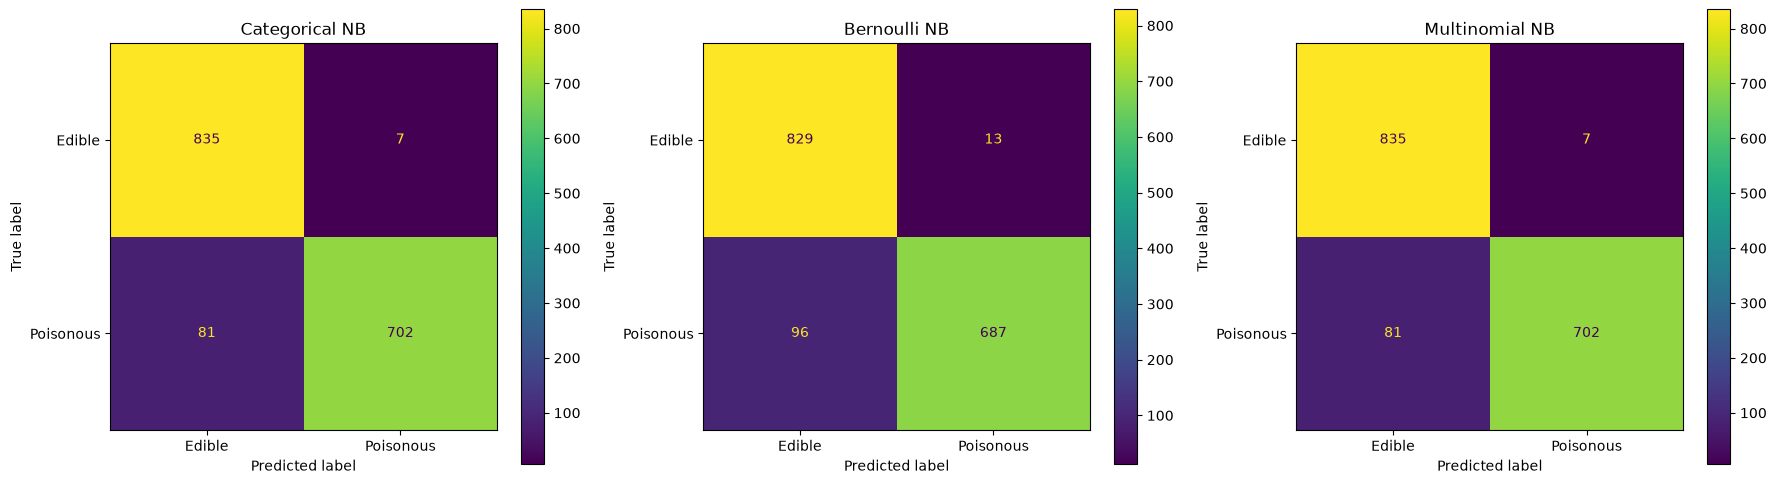

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Edible", "Poisonous"])
    disp.plot(ax=ax)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()


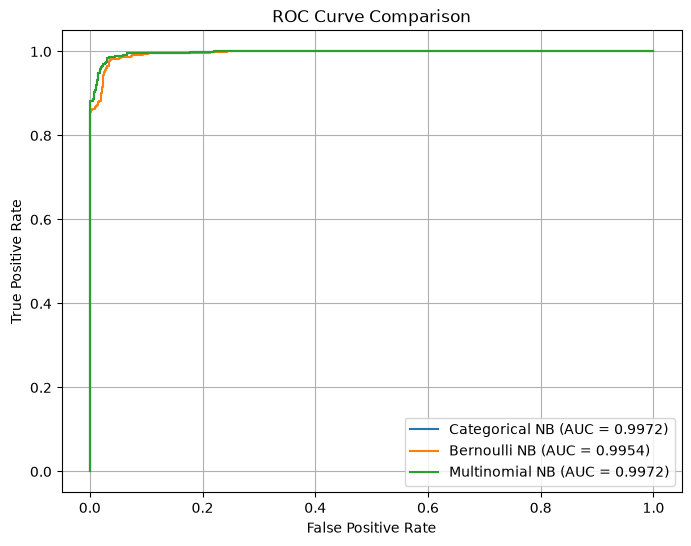

In [59]:
plt.figure(figsize=(8, 6))

for model, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='p')
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc_score:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig("roc.png", dpi=300)
plt.show()


# 5. Analisis

Berdasarkan hasil training, Categorical NB dan Multinomial NB memiliki hasil yang sama, yaitu accuracy **0.9458**, precision **0.9901**, recall **0.8966**, F1-score **0.9410**, dan ROC-AUC **0.9972**. Bernoulli NB memperoleh accuracy **0.9329**, precision **0.9814**, recall **0.8774**, F1-score **0.9265**, dan ROC-AUC **0.9954**.

Jika dibandingkan secara langsung, Categorical NB dan Multinomial NB lebih unggul dari Bernoulli NB sebesar 0.0129 pada accuracy, 0.0087 pada precision, 0.0192 pada recall, 0.0145 pada F1-score, dan 0.0018 pada ROC-AUC. Selisih ROC-AUC yang kecil menunjukkan bahwa ketiga model sama-sama sangat baik dalam mengurutkan sampel poisonous dan edible berdasarkan probabilitas. Hasil confusion matrix mengonfirmasi bahwa Categorical NB dan Multinomial NB memiliki pola prediksi yang identik, sedangkan Bernoulli NB mencatat jumlah kesalahan klasifikasi yang sedikit lebih tinggi. 

Seluruh model menghasilkan precision yang lebih tinggi daripada recall untuk kelas poisonous. Tingginya precision menunjukkan akurasi yang baik pada sampel yang diprediksi beracun. Namun, angka recall yang lebih rendah cukup fatal.

Perbedaan performa antar model sangat dipengaruhi oleh metode representasi data. Categorical NB memproses kode dari OrdinalEncoder sebagai indeks diskret, sebuah pendekatan yang paling selaras dengan karakteristik Mushroom Dataset yang full kategorikal. Sebaliknya, OneHotEncoder pada Bernoulli NB (biner 0/1) justru menghasilkan metrik yang lebih rendah. Sementara itu, Multinomial NB yang mengolah nilai one-hot encoding layaknya data frekuensi berhasil menyamai angka performa Categorical NB secara kebetulan pada dataset ini.

Beberapa hal yang cukup menarik, Berdasarkan analisis mengugnakan skor Cramér’s V, fitur `odor` teridentifikasi sebagai prediktor terkuat dan paling informatif dalam membedakan kelas jamur, sedangkan `veil-type` yang terendah akibat hanya ada 1 variable unik


# 6. Kesimpulan dan Saran

#### Kesimpulan
Categorical NB dan Multinomial NB memperoleh performa terbaik dengan accuracy 94,58%, sedangkan Bernoulli NB memperoleh 93,29%. Meskipun hasil Categorical NB dan Multinomial NB sama (kebetulan), Categorical NB lebih sesuai karena data yang digunakan seluruhnya bersifat kategorikal.

#### Saran
Eksperimen selanjutnya dapat menggunakan cross-validation agar hasil evaluasi lebih stabil. Selain itu, nilai parameter alpha dapat diuji untuk meningkatkan performa model, khususnya recall dalam mendeteksi jamur poisonous.